In [101]:
import yaml
import torch
import time
import matplotlib.pyplot as plt


from sfmpe.tasks.Gaussian import GaussianTask


config_path = './configs/gauss_config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)
device = 'cpu'
task = GaussianTask(config, device=device)
logger = task.logger
logger.info("Starting Gaussian task")

2026-04-29 14:19:32,437 - Gaussian - INFO - Starting Gaussian task


In [ ]:
# theta_0 = task.prior.sample((1, ))
theta_0 = torch.tensor([[-3.7413, 0]])
x = task.summarize(task.simulate(theta_0.expand(10000, -1)))
mean = torch.cat([x.mean(dim=0).unsqueeze(-1), torch.log(x.std(dim=0)).unsqueeze(-1)], dim=-1)
def sample_likelyhood(size):
    mean_sized = mean.unsqueeze(0)
    return mean_sized[..., 0] + mean_sized[..., 1] * torch.randn((size, *mean[:, 0].shape))
# plt.scatter(, s=4, alpha=0.4)
# plt.scatter(theta_0[:, 0], theta_0[:, 1], s=10, color="black")
# theta_pred = torch.cat([x.mean(dim=0).unsqueeze(-1), torch.log(x.std(dim=0)).unsqueeze(-1)], dim=-1)
# theta_pred_mean = theta_pred.mean(dim=0)
# theta_pred_std  = theta_pred.std(dim=0)
# plt.scatter(theta_pred_mean[0], theta_pred_mean[1], s=10, color="red")
# print(theta_0, theta_pred_mean, theta_pred_std)
sample_likelyhood(10000).std(dim=0).std()


tensor(0.0006)

In [ ]:
from sfmpe.inference.fm_estimator import FlowMatchingEstimator
from sfmpe.flow.flow_model import FlowModel
from sfmpe.flow.velocity import SimpleVelocityField
from sfmpe.flow.path import AffinePath
from sfmpe.core.distributions import Uniform, Normal


init_dist = Normal()
velocity_model = SimpleVelocityField(task.theta_dim, task.data_dim)
path = AffinePath()
flow_model = FlowModel(velocity_model, init_dist, path)
logger.info("Initialized flow model")

optimizer = torch.optim.Adam(flow_model.velocity_model.parameters(), lr=1e-4)
loss_fn = torch.nn.MSELoss()

fm_estimator = FlowMatchingEstimator(flow_model, optimizer, loss_fn)
logger.info("Initialized flow matching estimator")

2026-04-10 19:25:10,371 - Gaussian - INFO - Initialized flow model
2026-04-10 19:25:10,372 - Gaussian - INFO - Initialized flow matching estimator


2026-04-10 19:25:10,412 - Gaussian - INFO - Starting SFMPE for theta tensor([[-4.5664,  0.1524]])
2026-04-10 19:25:10,413 - Gaussian - INFO - RoundManager initialized with device: cpu
2026-04-10 19:25:10,414 - Gaussian - INFO - Task: GaussianTask
2026-04-10 19:25:10,415 - Gaussian - INFO - Estimator: FlowMatchingEstimator
2026-04-10 19:25:10,416 - Gaussian - INFO - Starting sequential training with 15 rounds
2026-04-10 19:25:10,417 - Gaussian - INFO - Simulations per round: 10000
2026-04-10 19:25:10,418 - Gaussian - INFO - Training kwargs: {'path': './models/SIR_2026-04-10_19_25_10.pth.tar.gz', 'epochs': 1000, 'show_every': 200}
2026-04-10 19:25:10,419 - Gaussian - INFO - --- Round 0/15 ---
2026-04-10 19:25:10,420 - Gaussian - INFO - Starting round 0 with 10000 simulations
2026-04-10 19:25:10,420 - Gaussian - DEBUG - Proposal distribution: <sfmpe.tasks.Gaussian.GaussianPrior object at 0x0000029BFAAF8A60>
2026-04-10 19:25:10,422 - Gaussian - DEBUG - x_0 shape torch.Size([1])
2026-04-10 

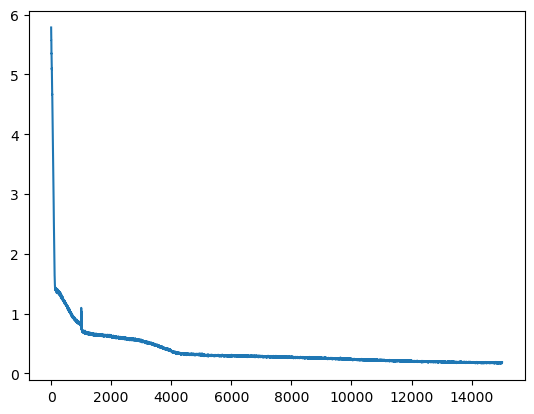

In [ ]:
from sfmpe.inference.sequential.round_manager import RoundManager
from sfmpe.inference.sequential.proposal import Proposal, ProposalParams

theta_0, x_0 = task.simulate_dataset((1,))
# print(x_0)
task.logger.info(f"Starting SFMPE for theta {theta_0}")

params = ProposalParams()
params.method = "NPE-A"
params.x_0 = x_0

datetime = time.strftime("%Y-%m-%d_%H_%M_%S")
path = f"./models/SIR_{datetime}.pth.tar.gz"

num_rounds = 15
sims_per_round = 3000
epochs = 1000
show_every = 200

manager = RoundManager(task, fm_estimator, params)
manager.run_sequential(num_rounds=num_rounds,
                       sims_per_round=sims_per_round,
                       path=path, epochs=epochs, 
                       show_every=show_every)
loss = manager.losses
plt.plot(loss)

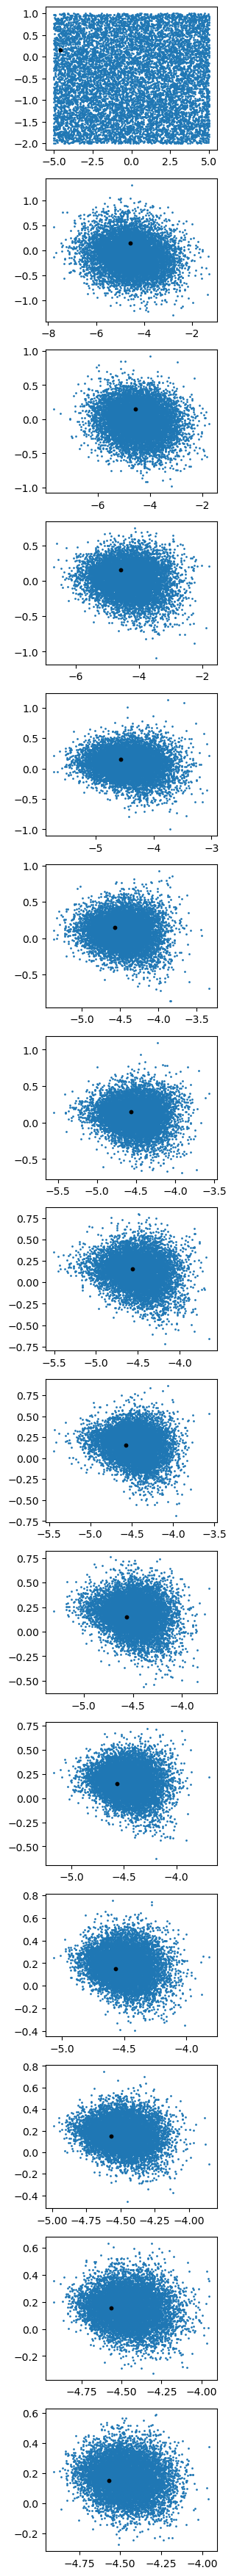

: 

In [ ]:
sim_store = manager.store

_, ax = plt.subplots(num_rounds, 1, figsize=(3, 3 * num_rounds))
for r in range(num_rounds):
    theta, x = sim_store.theta[r], sim_store.x[r]
    ax[r].scatter(theta[:, :, 0], theta[:, :, 1], s=1)
    ax[r].scatter(theta_0[:, 0], theta_0[:, 1], s=10, color="black")

    # plt.xlim((-4, 1))
    # plt.ylim((-3.1, -0.5))
    

In [ ]:
posterior = fm_estimator.build_posterior()
# theta, x_0 = sir_task.simulate_dataset((1,))
# x_0 = params.x_0
# x_0 += 0.01*torch.randn_like(x_0)
x_0_expanded = x_0.expand(10000, -1, -1)
theta_pred = posterior.sample(x_0_expanded, n_steps=32)
# i = 3
plt.scatter(theta_pred[:, :, 0], theta_pred[:, :, 1], s=1)
plt.scatter(theta_0[:, 0], theta_0[:, 1], s=10, color="black")
# plt.scatter(theta_pred[:, 0], theta_pred[:, 1], s=1)
# plt.scatter(theta_0[:, 0], theta_0[:, 1], s=10)
theta_0, theta_pred.mean(dim=0), theta_pred.std(dim=0) 

2026-04-10 19:30:25,941 - Gaussian - INFO - Building posterior...


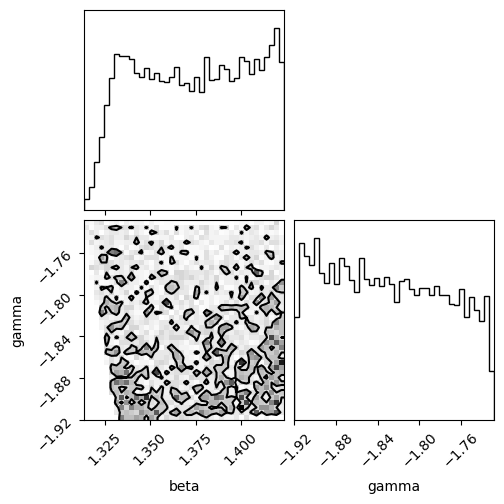

In [ ]:
import corner

for i in range(theta_pred.shape[1]):
    samples = theta_pred[:, i, :].numpy()
    fig = corner.corner(samples, bins=40, levels=[0.5], labels=['beta', 'gamma'],
                        plot_datapoints=False, plot_contours=True)